<a href="https://colab.research.google.com/github/Favyriite/Favyriite/blob/main/NO_show_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Direct link to the raw dataset hosted on GitHub
url = 'https://raw.githubusercontent.com/ksatola/Medical-Appointments-No-Shows/master/noshowappointments-kagglev2-may-2016.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [2]:
# 1. Convert all column names to lowercase and replace hyphens
df.columns = df.columns.str.lower().str.replace('-', '_')

# 2. Fix known typos in column names
df = df.rename(columns={'hipertension': 'hypertension', 'handcap': 'handicap'})

# 3. Drop the tracking IDs
df = df.drop(['patientid', 'appointmentid'], axis=1)

# 4. Convert 'no_show' target column (Yes -> 1, No -> 0)
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

# Display the updated dataset
df.head()

,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,0
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,0
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,0
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,0


In [3]:
df['no_show'].value_counts()

,count
no_show,
0,88208
1,22319


In [4]:
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

# Checking for the new data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   gender          110527 non-null  object             
 1   scheduledday    110527 non-null  datetime64[ns, UTC]
 2   appointmentday  110527 non-null  datetime64[ns, UTC]
 3   age             110527 non-null  int64              
 4   neighbourhood   110527 non-null  object             
 5   scholarship     110527 non-null  int64              
 6   hypertension    110527 non-null  int64              
 7   diabetes        110527 non-null  int64              
 8   alcoholism      110527 non-null  int64              
 9   handicap        110527 non-null  int64              
 10  sms_received    110527 non-null  int64              
 11  no_show         110527 non-null  int64              
dtypes: datetime64[ns, UTC](2), int64(8), object(2)
memory usage: 10.1+ MB


In [5]:
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

# Calculate wait time in days
df['wait_days'] = (df['appointmentday'] - df['scheduledday']).dt.days

# Drop text/date columns we don't need for the MVP
df = df.drop(['scheduledday', 'appointmentday', 'neighbourhood'], axis=1)

# Verify all columns are now numbers
print("Current data types:\n", df.dtypes)

Current data types:
 gender          object
age              int64
scholarship      int64
hypertension     int64
diabetes         int64
alcoholism       int64
handicap         int64
sms_received     int64
no_show          int64
wait_days        int64
dtype: object


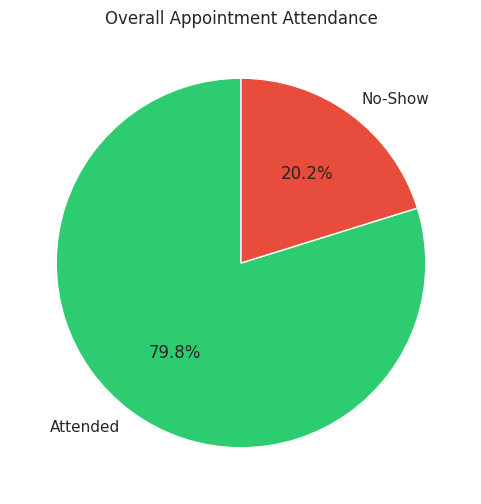

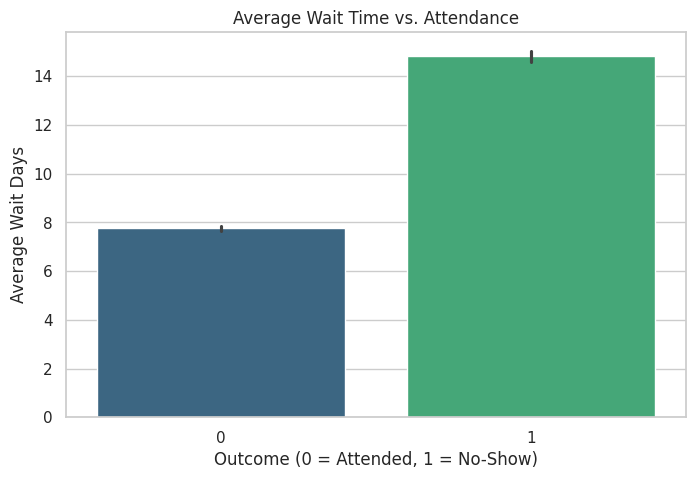

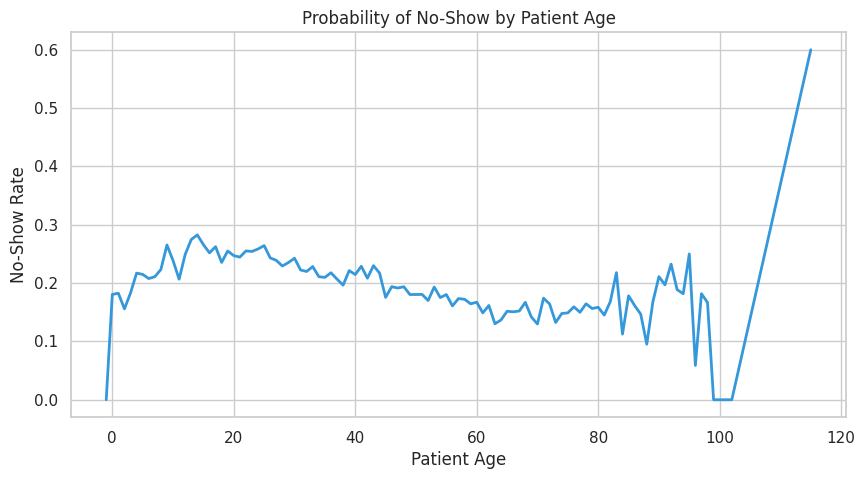

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# 1. PIE CHART: Overall No-Show Distribution
plt.figure(figsize=(6, 6))
df['no_show'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Attended', 'No-Show'],
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
plt.title('Overall Appointment Attendance')
plt.ylabel('') # Hides the default y-axis label for a cleaner look
plt.show()

# 2. BAR CHART: Wait Time Impact
plt.figure(figsize=(8, 5))
sns.barplot(x='no_show', y='wait_days', data=df, palette='viridis', hue='no_show', legend=False)
plt.title('Average Wait Time vs. Attendance')
plt.xlabel('Outcome (0 = Attended, 1 = No-Show)')
plt.ylabel('Average Wait Days')
plt.show()

# 3. LINE GRAPH: Age Trends
plt.figure(figsize=(10, 5))
age_trend = df.groupby('age')['no_show'].mean().reset_index()
sns.lineplot(x='age', y='no_show', data=age_trend, color='#3498db', linewidth=2)
plt.title('Probability of No-Show by Patient Age')
plt.xlabel('Patient Age')
plt.ylabel('No-Show Rate')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Convert categorical gender column to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)

# Define features (X) and the target we want to predict (y)
X = df.drop('no_show', axis=1)
y = df['no_show']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

print("Model training complete! ")

Model training complete! 


 Model Evaluation 
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     17669
           1       0.35      0.20      0.26      4437

    accuracy                           0.77     22106
   macro avg       0.59      0.56      0.56     22106
weighted avg       0.73      0.77      0.74     22106



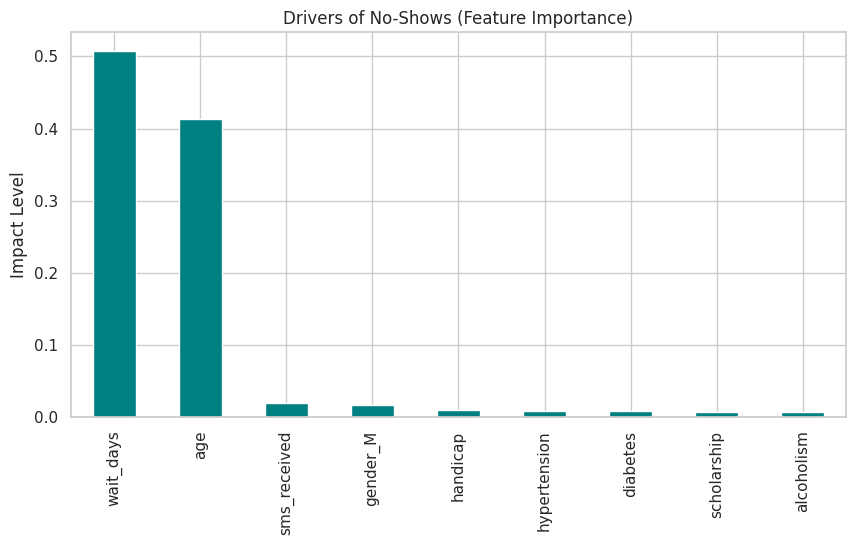

In [8]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# 1. Evaluation
y_pred = model.predict(X_test)
print(" Model Evaluation ")
print(classification_report(y_test, y_pred))

# 2. Drivers (Feature Importance)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='teal')
plt.title('Drivers of No-Shows (Feature Importance)')
plt.ylabel('Impact Level')
plt.show()

In [9]:
import gradio as gr
import pandas as pd

def predict_noshow(gender_text, age, scholarship_text, hypertension_text, diabetes_text, alcoholism_text, handicap, sms_received_text, wait_days):

    # Map text back to 0s and 1s to match the training set features
    # Note: 'gender_M' is 1 for Male, 0 for Female based on pd.get_dummies(drop_first=True)
    gender_M = 1 if gender_text == "Male" else 0
    scholarship = 1 if scholarship_text == "Yes" else 0
    hypertension = 1 if hypertension_text == "Yes" else 0
    diabetes = 1 if diabetes_text == "Yes" else 0
    alcoholism = 1 if alcoholism_text == "Yes" else 0
    sms_received = 1 if sms_received_text == "Yes" else 0

    # Use the EXACT column names used during model.fit()
    cols = ['age', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'wait_days', 'gender_M']
    input_df = pd.DataFrame([[age, scholarship, hypertension, diabetes, alcoholism, handicap, sms_received, wait_days, gender_M]], columns=cols)

    # Ensure column order matches X_train
    input_df = input_df[X.columns]

    # Calculate probabilities
    probabilities = model.predict_proba(input_df)[0]
    prob_attend = probabilities[0] * 100
    prob_noshow = probabilities[1] * 100

    # Formatted Markdown Output
    if prob_noshow > 50:
        result = f"### 🚨 HIGH RISK OF NO-SHOW\n\n**Model Confidence:** {prob_noshow:.1f}%\n\n*Recommendation: Flag for targeted SMS/Call reminder.*"
    else:
        result = f"### ✅ LIKELY TO ATTEND\n\n**Model Confidence:** {prob_attend:.1f}%\n\n*Status: Routine processing.*"

    return result

# Build the layout
with gr.Blocks() as interface:

    gr.HTML("""
        <div style='background-color: #e0f2fe; padding: 20px; border-radius: 10px; border: 2px solid #bae6fd; text-align: center; margin-bottom: 20px;'>
            <h1 style='color: #0369a1; margin: 0; font-family: sans-serif;'>🏥 PHC Appointment Predictor Dashboard</h1>
            <p style='color: #0f172a; font-size: 16px; margin-top: 5px; font-family: sans-serif;'>Enter patient details to predict appointment attendance.</p>
        </div>
    """)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🧑‍⚕️ Patient Information")
            age = gr.Slider(minimum=0, maximum=115, step=1, value=30, label="Patient Age")
            wait_days = gr.Slider(minimum=0, maximum=180, step=1, value=10, label="Wait Time (Days)")

            with gr.Row():
                gender_text = gr.Dropdown(choices=["Female", "Male"], value="Female", label="Gender")
                handicap = gr.Dropdown(choices=[0, 1, 2, 3, 4], value=0, label="Handicap Level")

            gr.Markdown("### 📋 Medical History")
            with gr.Row():
                hypertension_text = gr.Radio(choices=["No", "Yes"], value="No", label="Hypertension")
                diabetes_text = gr.Radio(choices=["No", "Yes"], value="No", label="Diabetes")
            with gr.Row():
                alcoholism_text = gr.Radio(choices=["No", "Yes"], value="No", label="Alcoholism")
                scholarship_text = gr.Radio(choices=["No", "Yes"], value="No", label="Welfare Scholarship")

            sms_received_text = gr.Radio(choices=["No", "Yes"], value="No", label="SMS Reminder")
            predict_btn = gr.Button("Analyze Risk", variant="primary")

        with gr.Column():
            gr.Markdown("### 📊 Risk Analysis Output")
            output_markdown = gr.Markdown("Enter patient details and click **Analyze Risk** to view the prediction.")

    predict_btn.click(
        fn=predict_noshow,
        inputs=[gender_text, age, scholarship_text, hypertension_text, diabetes_text, alcoholism_text, handicap, sms_received_text, wait_days],
        outputs=output_markdown
    )

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://da8ff4f8c9b878fee8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
import joblib
joblib.dump(model, 'noshow_model.joblib')

['noshow_model.joblib']